Number of nodes: 30
Number of edges: 60
Degree set: {4}
Is 4-regular? True
Ollivier-Ricci curvature on 60 edges:
  mean  = -0.2500
  std   = 0.0000
  min   = -0.2500
  max   = -0.2500


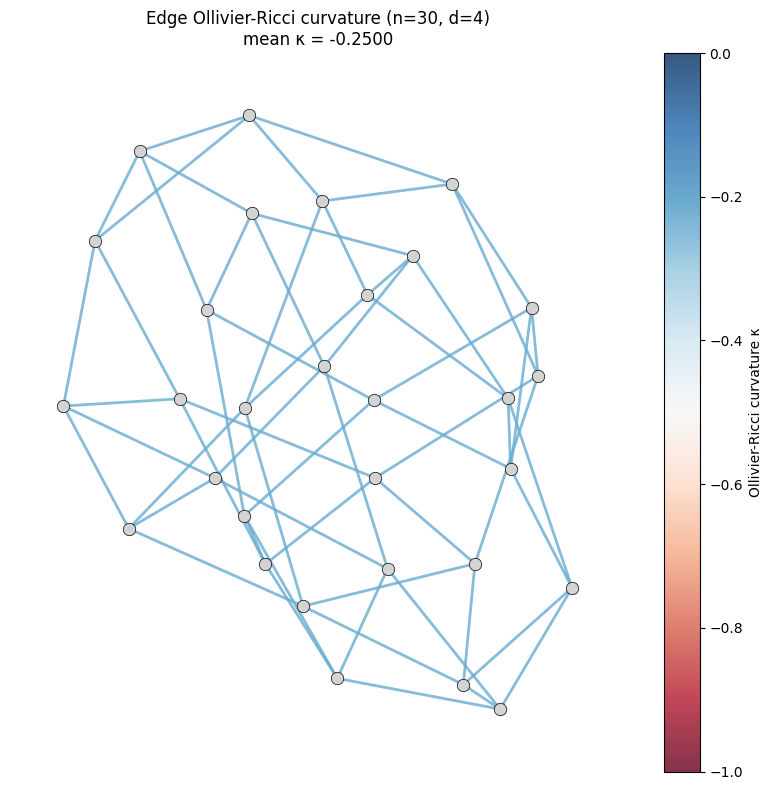

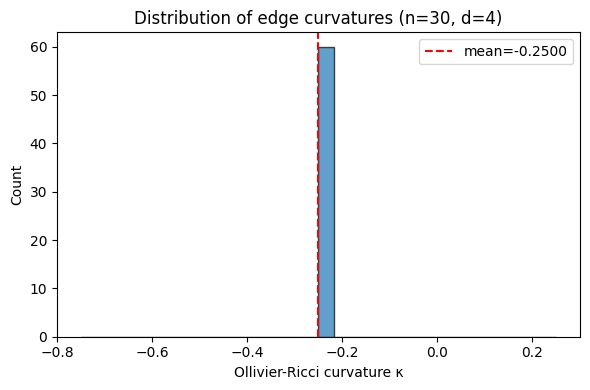

max |U†U - I| = 2.220446049250313e-15
done; max |z| = 0.09178346658598308


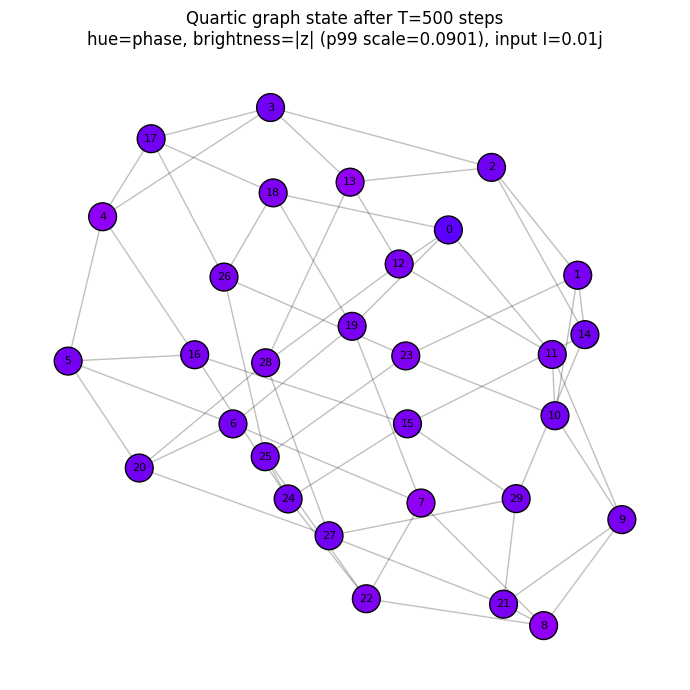

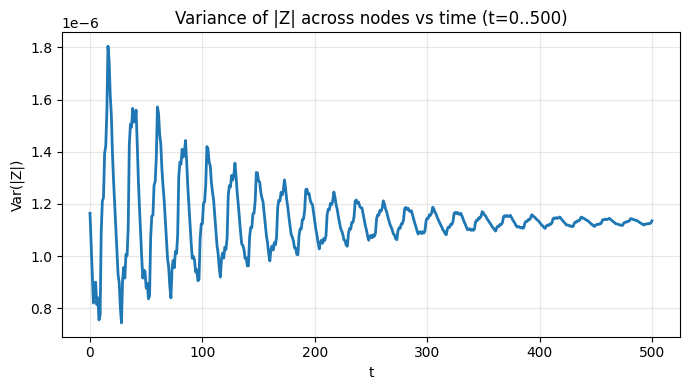

Var(|Z|) at t=0: 1.16443e-06
Var(|Z|) at t=500: 1.13524e-06


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm
from matplotlib.colors import hsv_to_rgb
np.random.seed(0)
import networkx as nx
from scipy.optimize import linprog

G = nx.Graph()
n = 30
d = 4
adj = {
    0:  [11,12,18,19],
    1:  [2, 10, 23, 14],
    2:  [1, 3, 13, 14],
    3:  [2, 4, 13, 17],
    4:  [3, 5, 16, 17],
    5:  [4, 6, 16, 20],
    6:  [5, 7, 19, 20],
    7:  [6, 8, 19, 22],
    8:  [9, 7, 21, 22],
    9:  [8, 10, 11, 21],
    10: [1, 9, 11, 23],
    11: [10, 12, 9, 0],
    12: [11, 13, 28, 0],
    13: [2, 3, 12, 28],
    14: [1, 2, 29, 15],
    15: [14, 16, 24, 29],
    16: [4, 5, 15, 24],
    17: [3, 4, 18, 26],
    18: [17, 19, 26, 0],
    19: [6, 7, 18, 0],
    20: [5, 6, 27, 28],
    21: [8, 9, 27, 29],
    22: [7, 8, 24, 25],
    23: [1, 10, 25, 26],
    24: [15, 16, 22, 25],
    25: [22, 23, 24, 26],
    26: [17, 18, 23, 25],
    27: [20, 21, 28, 29],
    28: [12, 13, 20, 27],
    29: [14, 15, 21, 27],
}

for u, nbrs in adj.items():
    for v in nbrs:
        G.add_edge(u, v)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Degree set:", set(dict(G.degree()).values()))
print("Is 4-regular?", all(d == 4 for _, d in G.degree()))

# --- Ollivier-Ricci curvature ---
def ollivier_ricci_curvature(G, u, v, alpha=0.0):
    """
    Compute Ollivier-Ricci curvature on edge (u,v).
    
    alpha=0  : lazy random walk with uniform measure on neighbors (standard Ollivier).
    alpha>0  : fraction of mass kept at the node itself (idleness).
               mu_u = alpha * delta_u + (1-alpha) * uniform(neighbors(u))
    """
    Nu = list(G.neighbors(u))
    Nv = list(G.neighbors(v))
    
    # Support sets
    supp_u = [u] + Nu
    supp_v = [v] + Nv
    all_nodes = list(set(supp_u + supp_v))
    node_idx = {node: i for i, node in enumerate(all_nodes)}
    m = len(all_nodes)
    
    # Measures mu_u and mu_v
    mu = np.zeros(m)
    mv = np.zeros(m)
    
    mu[node_idx[u]] = alpha
    for nb in Nu:
        mu[node_idx[nb]] += (1 - alpha) / len(Nu)
    
    mv[node_idx[v]] = alpha
    for nb in Nv:
        mv[node_idx[nb]] += (1 - alpha) / len(Nv)
    
    # Distance matrix between support nodes
    D = np.zeros((m, m))
    for i, ni in enumerate(all_nodes):
        for j, nj in enumerate(all_nodes):
            if i <= j:
                d = nx.shortest_path_length(G, ni, nj)
                D[i, j] = d
                D[j, i] = d
    
    # Solve optimal transport (Wasserstein-1) via LP
    # Variables: pi[i,j] for i in supp(mu), j in supp(mv)
    c = D.flatten()  # cost vector
    
    # Constraints: row sums = mu, col sums = mv
    A_eq = []
    b_eq = []
    
    # Row constraints: sum_j pi[i,j] = mu[i]
    for i in range(m):
        row = np.zeros(m * m)
        row[i * m:(i + 1) * m] = 1.0
        A_eq.append(row)
        b_eq.append(mu[i])
    
    # Column constraints: sum_i pi[i,j] = mv[j]
    for j in range(m):
        col = np.zeros(m * m)
        col[j::m] = 1.0
        A_eq.append(col)
        b_eq.append(mv[j])
    
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    bounds = [(0, None)] * (m * m)
    
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    W1 = res.fun  # Wasserstein-1 distance
    
    d_uv = nx.shortest_path_length(G, u, v)
    return 1.0 - W1 / d_uv

edge_curvatures = {}
for u, v in G.edges():
    kappa = ollivier_ricci_curvature(G, u, v, alpha=0.0)
    edge_curvatures[(u, v)] = kappa

curvature_vals = np.array(list(edge_curvatures.values()))

print(f"Ollivier-Ricci curvature on {len(edge_curvatures)} edges:")
print(f"  mean  = {np.mean(curvature_vals):.4f}")
print(f"  std   = {np.std(curvature_vals):.4f}")
print(f"  min   = {np.min(curvature_vals):.4f}")
print(f"  max   = {np.max(curvature_vals):.4f}")

# --- Visualize: color edges by curvature ---
pos = nx.spring_layout(G, seed=0)

fig, ax = plt.subplots(figsize=(8, 8))

edges = list(edge_curvatures.keys())
colors = [edge_curvatures[e] for e in edges]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=80, node_color="lightgray",
                       edgecolors="black", linewidths=0.5)
ec = nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, edge_color=colors,
                            edge_cmap=plt.cm.RdBu, width=2.0, alpha=0.8,
                            edge_vmin=-1, edge_vmax=0)
plt.colorbar(ec, ax=ax, label="Ollivier-Ricci curvature κ")

ax.set_title(f"Edge Ollivier-Ricci curvature (n={n}, d={d})\n"
             f"mean κ = {np.mean(curvature_vals):.4f}")
ax.axis("off")
plt.tight_layout()
plt.show()

# --- Histogram ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(curvature_vals, bins=30, edgecolor="black", alpha=0.7)
ax.axvline(np.mean(curvature_vals), color="red", linestyle="--", label=f"mean={np.mean(curvature_vals):.4f}")
ax.set_xlabel("Ollivier-Ricci curvature κ")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of edge curvatures (n={n}, d={d})")
ax.legend()
plt.tight_layout()
plt.show()
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm
from matplotlib.colors import hsv_to_rgb
np.random.seed(0)


def phi(Z):
    return Z / np.sqrt(1.0 + np.abs(Z)**2)

# Random quartic (4-regular) graph named Z
Z = G
T = 500
I = 0.0 + 0.01j          # constant complex input added to node 0 each step
dt = 1.0                  # optional scale for the generator i*L
# Graph Laplacian L (Hermitian/symmetric) and anti-Hermitian generator A = i*L
A_adj = nx.to_numpy_array(Z, nodelist=range(n), dtype=float)
deg = A_adj.sum(axis=1)
L = np.diag(deg) - A_adj                 # combinatorial Laplacian, symmetric real
A = 1j * dt * L                          # anti-Hermitian (since L^T=L => (iL)† = -iL)
# Unitary kernel
U = expm(A)                              # should be unitary (up to numerical error)

# Quick sanity check: U†U ≈ I
unitarity_err = np.max(np.abs(U.conj().T @ U - np.eye(n)))
print("max |U†U - I| =", unitarity_err)

# Recurrent update: z <- phi(U z + I_vec)
z = np.zeros(n, dtype=np.complex128)     # node states
I_vec = np.zeros(n, dtype=np.complex128)
I_vec[0] = I

for t in range(T):
    z_lin = U @ z + I_vec
    z = phi(z_lin)

print("done; max |z| =", np.max(np.abs(z)))

# Visualization: phase as hue, magnitude as brightness
mag = np.abs(z)
scale = np.percentile(mag, 99) if np.any(mag) else 1.0
scale = float(scale) if scale > 0 else 1.0
v = np.clip(mag / scale, 0.0, 1.0)                 # value/brightness
h = (np.angle(z) + np.pi) / (2 * np.pi)            # hue in [0,1]
s = np.ones_like(h)                                 # full saturation
rgb = hsv_to_rgb(np.stack([h, s, v], axis=-1))
pos = nx.spring_layout(Z, seed=0)  # layout for visualization (not part of dynamics)

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(Z, pos, alpha=0.25, width=1.0)
nx.draw_networkx_nodes(
    Z, pos,
    node_color=rgb,
    node_size=400,
    linewidths=1.0,
    edgecolors="black"
)
nx.draw_networkx_labels(Z, pos, font_size=8)

plt.title(f"Quartic graph state after T={T} steps\n"
          f"hue=phase, brightness=|z| (p99 scale={scale:.3g}), input I={I}")
plt.axis("off")
plt.tight_layout()
plt.show()
import numpy as np
import matplotlib.pyplot as plt


def compute_var_abs_z_over_time(U, phi, T, I_vec=None, z0=None):
    """
    Compute Var(|z_t|) for t = 0..T under: z_{t+1} = phi(U @ z_t + I_vec)

    Returns
    -------
    t_axis : (T+1,) ndarray
    var_abs : (T+1,) ndarray
    z_last : (n,) ndarray
    """
    n = U.shape[0]

    if z0 is None:
        z = np.zeros(n, dtype=np.complex128)
    else:
        z = np.asarray(z0, dtype=np.complex128).copy()

    if I_vec is None:
        I_vec_use = np.zeros(n, dtype=np.complex128)
    else:
        I_vec_use = np.asarray(I_vec, dtype=np.complex128)

    T = int(T)
    t_axis = np.arange(T + 1)
    var_abs = np.empty(T + 1, dtype=float)

    var_abs[0] = np.var(np.abs(z))
    for t in range(1, T + 1):
        z = phi(U @ z + I_vec_use)
        var_abs[t] = np.var(np.abs(z))

    return t_axis, var_abs, z


# ---- Generalized usage with variables from earlier cells ----
required = ["U", "phi", "T"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing)
        + ". Run your simulation setup cell first."
    )

I_vec_use = I_vec if "I_vec" in globals() else None
z0_use = z if "z" in globals() else None

t_axis, var_abs, z_last = compute_var_abs_z_over_time(
    U=U,
    phi=phi,
    T=T,
    I_vec=I_vec_use,
    z0=z0_use
)

plt.figure(figsize=(7, 4))
plt.plot(t_axis, var_abs, lw=2)
plt.xlabel("t")
plt.ylabel("Var(|Z|)")
plt.title(f"Variance of |Z| across nodes vs time (t=0..{T})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Var(|Z|) at t=0: {var_abs[0]:.6g}")
print(f"Var(|Z|) at t={T}: {var_abs[-1]:.6g}")

G1 = G

z = np.zeros(n, dtype=np.complex128)
Z_hist = np.zeros((T, n), dtype=np.complex128)

for t in range(T):
    z_lin = U @ z + I_vec
    z = phi(z_lin)
    Z_hist[t] = z

G: G_torus_5x6
n nodes: 30 | m edges: 60
degree set: [4]
m should equal 2*n for 4-regular undirected: 60 vs 60
neighbors(0) = [1, 5, 6, 24]
Ollivier-Ricci curvature on 60 edges:
  mean  = 0.0000
  std   = 0.0000
  min   = 0.0000
  max   = 0.0000


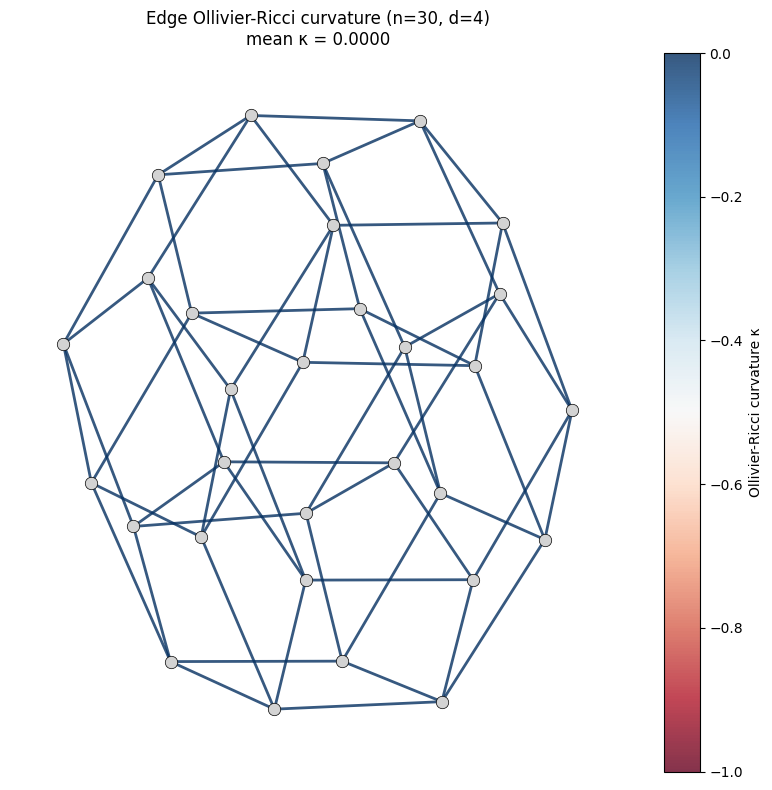

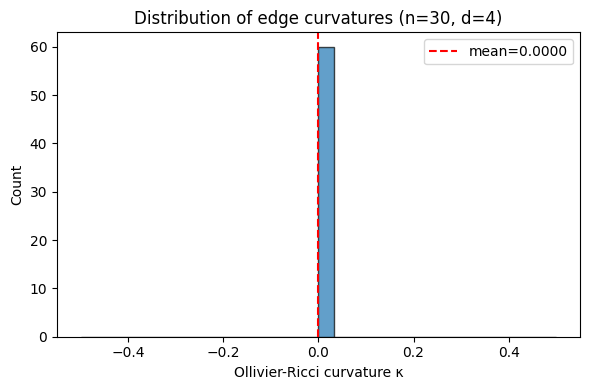

max |U†U - I| = 1.5543122344752192e-15
done; max |z| = 0.09070497468253051


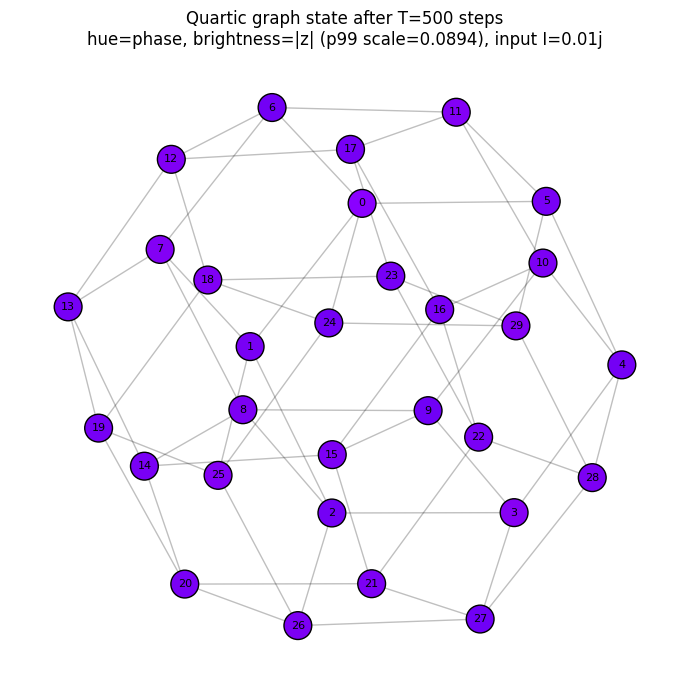

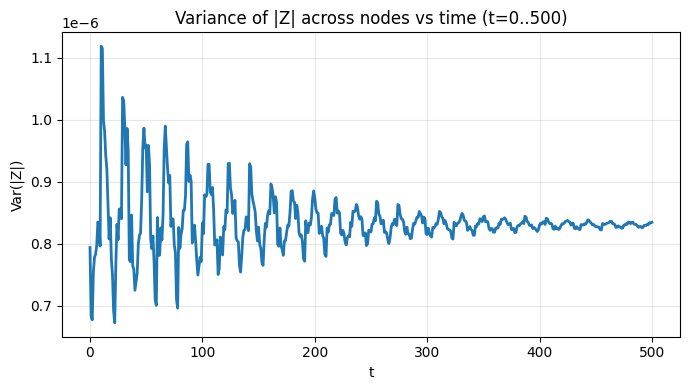

Var(|Z|) at t=0: 7.94117e-07
Var(|Z|) at t=500: 8.34663e-07


In [2]:
# Cell: #VSC-27ef2dcb
import numpy as np
import networkx as nx
from scipy.optimize import linprog
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm
from matplotlib.colors import hsv_to_rgb
np.random.seed(0)
n = 30
d = 4
def torus_grid_graph(rows: int, cols: int, *, label: str = "G") -> nx.Graph:
    """
    2D periodic grid (torus) with rows*cols nodes and degree 4.

    Nodes are relabeled to integers 0..(rows*cols-1) via: idx = r*cols + c.
    """
    G2 = nx.grid_2d_graph(rows, cols, periodic=True)  # nodes are (r,c)
    mapping = {(r, c): r * cols + c for r, c in G2.nodes()}
    Gint = nx.relabel_nodes(G2, mapping, copy=True)
    Gint.name = f"{label}_torus_{rows}x{cols}"
    return Gint

# NOTE: a 100x100 periodic grid has 10,000 nodes (not 1,000).
# If you truly want n=1000, pick any factorization like 20x50 or 25x40.
rows, cols = 5, 6  # 20*50 = 1000 nodes; change to (100,100) for 10,000 nodes
G = torus_grid_graph(rows, cols, label="G")

n = G.number_of_nodes()
m = G.number_of_edges()
deg_vals = [d for _, d in G.degree()]
print("G:", G.name)
print("n nodes:", n, "| m edges:", m)
print("degree set:", sorted(set(deg_vals)))  # should be [4]
print("m should equal 2*n for 4-regular undirected:", m, "vs", 2 * n)

# Example: neighbors of node i (0-indexed)
i = 0
print(f"neighbors({i}) =", sorted(G.neighbors(i)))

# If you need the adjacency matrix: WARNING it's n x n (huge for 10,000).
# A_adj = nx.to_numpy_array(G, nodelist=range(n), dtype=np.int8)
# --- Ollivier-Ricci curvature ---
def ollivier_ricci_curvature(G, u, v, alpha=0.0):
    """
    Compute Ollivier-Ricci curvature on edge (u,v).
    
    alpha=0  : lazy random walk with uniform measure on neighbors (standard Ollivier).
    alpha>0  : fraction of mass kept at the node itself (idleness).
               mu_u = alpha * delta_u + (1-alpha) * uniform(neighbors(u))
    """
    Nu = list(G.neighbors(u))
    Nv = list(G.neighbors(v))
    
    # Support sets
    supp_u = [u] + Nu
    supp_v = [v] + Nv
    all_nodes = list(set(supp_u + supp_v))
    node_idx = {node: i for i, node in enumerate(all_nodes)}
    m = len(all_nodes)
    
    # Measures mu_u and mu_v
    mu = np.zeros(m)
    mv = np.zeros(m)
    
    mu[node_idx[u]] = alpha
    for nb in Nu:
        mu[node_idx[nb]] += (1 - alpha) / len(Nu)
    
    mv[node_idx[v]] = alpha
    for nb in Nv:
        mv[node_idx[nb]] += (1 - alpha) / len(Nv)
    
    # Distance matrix between support nodes
    D = np.zeros((m, m))
    for i, ni in enumerate(all_nodes):
        for j, nj in enumerate(all_nodes):
            if i <= j:
                d = nx.shortest_path_length(G, ni, nj)
                D[i, j] = d
                D[j, i] = d
    
    # Solve optimal transport (Wasserstein-1) via LP
    # Variables: pi[i,j] for i in supp(mu), j in supp(mv)
    c = D.flatten()  # cost vector
    
    # Constraints: row sums = mu, col sums = mv
    A_eq = []
    b_eq = []
    
    # Row constraints: sum_j pi[i,j] = mu[i]
    for i in range(m):
        row = np.zeros(m * m)
        row[i * m:(i + 1) * m] = 1.0
        A_eq.append(row)
        b_eq.append(mu[i])
    
    # Column constraints: sum_i pi[i,j] = mv[j]
    for j in range(m):
        col = np.zeros(m * m)
        col[j::m] = 1.0
        A_eq.append(col)
        b_eq.append(mv[j])
    
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    bounds = [(0, None)] * (m * m)
    
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    W1 = res.fun  # Wasserstein-1 distance
    
    d_uv = nx.shortest_path_length(G, u, v)
    return 1.0 - W1 / d_uv


# --- Compute curvature for every edge ---

edge_curvatures = {}
for u, v in G.edges():
    kappa = ollivier_ricci_curvature(G, u, v, alpha=0.0)
    edge_curvatures[(u, v)] = kappa

curvature_vals = np.array(list(edge_curvatures.values()))

print(f"Ollivier-Ricci curvature on {len(edge_curvatures)} edges:")
print(f"  mean  = {np.mean(curvature_vals):.4f}")
print(f"  std   = {np.std(curvature_vals):.4f}")
print(f"  min   = {np.min(curvature_vals):.4f}")
print(f"  max   = {np.max(curvature_vals):.4f}")

# --- Visualize: color edges by curvature ---
pos = nx.spring_layout(G, seed=0)

fig, ax = plt.subplots(figsize=(8, 8))

edges = list(edge_curvatures.keys())
colors = [edge_curvatures[e] for e in edges]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=80, node_color="lightgray",
                       edgecolors="black", linewidths=0.5)
ec = nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, edge_color=colors,
                            edge_cmap=plt.cm.RdBu, width=2.0, alpha=0.8,
                            edge_vmin=-1, edge_vmax=0)
plt.colorbar(ec, ax=ax, label="Ollivier-Ricci curvature κ")

ax.set_title(f"Edge Ollivier-Ricci curvature (n={n}, d={d})\n"
             f"mean κ = {np.mean(curvature_vals):.4f}")
ax.axis("off")
plt.tight_layout()
plt.show()

# --- Histogram ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(curvature_vals, bins=30, edgecolor="black", alpha=0.7)
ax.axvline(np.mean(curvature_vals), color="red", linestyle="--", label=f"mean={np.mean(curvature_vals):.4f}")
ax.set_xlabel("Ollivier-Ricci curvature κ")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of edge curvatures (n={n}, d={d})")
ax.legend()
plt.tight_layout()
plt.show()
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm
from matplotlib.colors import hsv_to_rgb
np.random.seed(0)

# Use the graph G built in Cell 5 (torus) / Cell 6 (ORC)
Z = G
n = Z.number_of_nodes()
d = Z.degree(0)           # degree of node 0 (all nodes are 4-regular on the torus)
T = 500
I = 0.0 + 0.01j          # constant complex input added to node 0 each step
dt = 1.0                  # optional scale for the generator i*L

def phi(Z):
    return Z / np.sqrt(1.0 + np.abs(Z)**2)

# Graph Laplacian L (Hermitian/symmetric) and anti-Hermitian generator A = i*L
A_adj = nx.to_numpy_array(Z, nodelist=range(n), dtype=float)
deg = A_adj.sum(axis=1)
L = np.diag(deg) - A_adj                 # combinatorial Laplacian, symmetric real
A = 1j * dt * L                          # anti-Hermitian (since L^T=L => (iL)† = -iL)
# Unitary kernel
U = expm(A)                              # should be unitary (up to numerical error)

# Quick sanity check: U†U ≈ I
unitarity_err = np.max(np.abs(U.conj().T @ U - np.eye(n)))
print("max |U†U - I| =", unitarity_err)

# Recurrent update: z <- phi(U z + I_vec)
z = np.zeros(n, dtype=np.complex128)     # node states
I_vec = np.zeros(n, dtype=np.complex128)
I_vec[0] = I

for t in range(T):
    z_lin = U @ z + I_vec
    z = phi(z_lin)

print("done; max |z| =", np.max(np.abs(z)))

# Visualization: phase as hue, magnitude as brightness
mag = np.abs(z)
scale = np.percentile(mag, 99) if np.any(mag) else 1.0
scale = float(scale) if scale > 0 else 1.0
v = np.clip(mag / scale, 0.0, 1.0)                 # value/brightness
h = (np.angle(z) + np.pi) / (2 * np.pi)            # hue in [0,1]
s = np.ones_like(h)                                 # full saturation
rgb = hsv_to_rgb(np.stack([h, s, v], axis=-1))
pos = nx.spring_layout(Z, seed=0)  # layout for visualization (not part of dynamics)

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(Z, pos, alpha=0.25, width=1.0)
nx.draw_networkx_nodes(
    Z, pos,
    node_color=rgb,
    node_size=400,
    linewidths=1.0,
    edgecolors="black"
)
nx.draw_networkx_labels(Z, pos, font_size=8)

plt.title(f"Quartic graph state after T={T} steps\n"
          f"hue=phase, brightness=|z| (p99 scale={scale:.3g}), input I={I}")
plt.axis("off")
plt.tight_layout()
plt.show()
import numpy as np
import matplotlib.pyplot as plt


def compute_var_abs_z_over_time(U, phi, T, I_vec=None, z0=None):
    """
    Compute Var(|z_t|) for t = 0..T under: z_{t+1} = phi(U @ z_t + I_vec)

    Returns
    -------
    t_axis : (T+1,) ndarray
    var_abs : (T+1,) ndarray
    z_last : (n,) ndarray
    """
    n = U.shape[0]

    if z0 is None:
        z = np.zeros(n, dtype=np.complex128)
    else:
        z = np.asarray(z0, dtype=np.complex128).copy()

    if I_vec is None:
        I_vec_use = np.zeros(n, dtype=np.complex128)
    else:
        I_vec_use = np.asarray(I_vec, dtype=np.complex128)

    T = int(T)
    t_axis = np.arange(T + 1)
    var_abs = np.empty(T + 1, dtype=float)

    var_abs[0] = np.var(np.abs(z))
    for t in range(1, T + 1):
        z = phi(U @ z + I_vec_use)
        var_abs[t] = np.var(np.abs(z))

    return t_axis, var_abs, z


# ---- Generalized usage with variables from earlier cells ----
required = ["U", "phi", "T"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required variables: " + ", ".join(missing)
        + ". Run your simulation setup cell first."
    )

I_vec_use = I_vec if "I_vec" in globals() else None
z0_use = z if "z" in globals() else None

t_axis, var_abs, z_last = compute_var_abs_z_over_time(
    U=U,
    phi=phi,
    T=T,
    I_vec=I_vec_use,
    z0=z0_use
)

plt.figure(figsize=(7, 4))
plt.plot(t_axis, var_abs, lw=2)
plt.xlabel("t")
plt.ylabel("Var(|Z|)")
plt.title(f"Variance of |Z| across nodes vs time (t=0..{T})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Var(|Z|) at t=0: {var_abs[0]:.6g}")
print(f"Var(|Z|) at t={T}: {var_abs[-1]:.6g}")

G2 = G

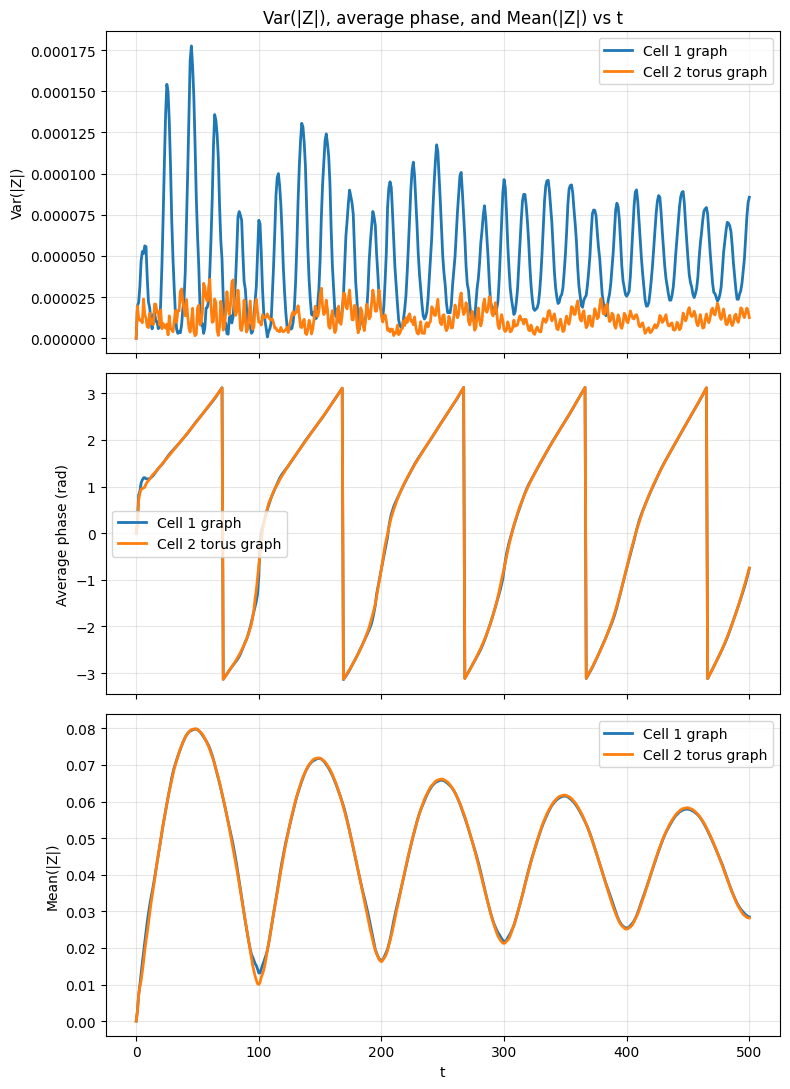

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm


def phi(z):
    return z / np.sqrt(1.0 + np.abs(z)**2)


def build_graph_cell1():
    """Manual 30-node graph (same as Cell 1)."""
    adj = {
        0: [11, 12, 18, 19],
        1: [2, 10, 23, 14],
        2: [1, 3, 13, 14],
        3: [2, 4, 13, 17],
        4: [3, 5, 16, 17],
        5: [4, 6, 16, 20],
        6: [5, 7, 19, 20],
        7: [6, 8, 19, 22],
        8: [9, 7, 21, 22],
        9: [8, 10, 11, 21],
        10: [1, 9, 11, 23],
        11: [10, 12, 9, 0],
        12: [11, 13, 28, 0],
        13: [2, 3, 12, 28],
        14: [1, 2, 29, 15],
        15: [14, 16, 24, 29],
        16: [4, 5, 15, 24],
        17: [3, 4, 18, 26],
        18: [17, 19, 26, 0],
        19: [6, 7, 18, 0],
        20: [5, 6, 27, 28],
        21: [8, 9, 27, 29],
        22: [7, 8, 24, 25],
        23: [1, 10, 25, 26],
        24: [15, 16, 22, 25],
        25: [22, 23, 24, 26],
        26: [17, 18, 23, 25],
        27: [20, 21, 28, 29],
        28: [12, 13, 20, 27],
        29: [14, 15, 21, 27],
    }
    G = nx.Graph()
    for u, nbrs in adj.items():
        for v in nbrs:
            G.add_edge(u, v)
    return G


def build_graph_cell2(rows=5, cols=6):
    """Periodic torus graph with rows*cols nodes."""
    G = nx.grid_2d_graph(rows, cols, periodic=True)
    mapping = {(r, c): r * cols + c for r, c in G.nodes()}
    return nx.relabel_nodes(G, mapping, copy=True)


def compute_curves(
    graph,
    T=500,
    dt=1.0,
    input_nodes=(0,),
    I_dc=0.0 + 0.01j,
    I_amp=0.0001,
    omega=2 * np.pi / 50,
    phase0=0.0,
):
    """
    Simulate z_{t+1} = phi(U z_t + I_vec(t)) and return:
      - Var(|z_t|)
      - circular mean phase
      - Mean(|z_t|)

    Periodic input:
      I_t = I_dc + I_amp * exp(i * (omega*t + phase0))
    """
    n = graph.number_of_nodes()
    A_adj = nx.to_numpy_array(graph, nodelist=range(n), dtype=float)
    L = np.diag(A_adj.sum(axis=1)) - A_adj
    U = expm(1j * dt * L)

    z = np.zeros(n, dtype=np.complex128)

    t_axis = np.arange(T + 1)
    var_abs = np.empty(T + 1, dtype=float)
    mean_phase = np.empty(T + 1, dtype=float)
    mean_abs = np.empty(T + 1, dtype=float)

    var_abs[0] = np.var(np.abs(z))
    mean_phase[0] = np.angle(np.mean(np.exp(1j * np.angle(z))))
    mean_abs[0] = np.mean(np.abs(z))

    input_nodes = np.atleast_1d(input_nodes)

    for t in range(1, T + 1):
        I_t = I_dc + I_amp * np.exp(1j * (omega * t + phase0))
        I_vec = np.zeros(n, dtype=np.complex128)
        I_vec[input_nodes] = I_t
        z = phi(U @ z + I_vec)
        var_abs[t] = np.var(np.abs(z))
        mean_phase[t] = np.angle(np.mean(np.exp(1j * np.angle(z))))
        mean_abs[t] = np.mean(np.abs(z))

    return t_axis, var_abs, mean_phase, mean_abs


# Self-contained graph definitions
G1 = build_graph_cell1()
G2 = build_graph_cell2(rows=5, cols=6)

# Parameters
T_plot = 500
input_nodes = np.arange(8)
I_dc = 0.0 + 0.0j
I_amp = 0.01
omega = 2 * np.pi / 100

phase0 = np.pi / 4

# Run both graphs with same settings
t1, var1, phase1, mean1 = compute_curves(
    G1, T=T_plot, input_nodes=input_nodes, I_dc=I_dc, I_amp=I_amp, omega=omega, phase0=phase0
)
t2, var2, phase2, mean2 = compute_curves(
    G2, T=T_plot, input_nodes=input_nodes, I_dc=I_dc, I_amp=I_amp, omega=omega, phase0=phase0
)

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

axes[0].plot(t1, var1, lw=2, label="Cell 1 graph")
axes[0].plot(t2, var2, lw=2, label="Cell 2 torus graph")
axes[0].set_ylabel("Var(|Z|)")
axes[0].set_title("Var(|Z|), average phase, and Mean(|Z|) vs t")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(t1, phase1, lw=2, label="Cell 1 graph")
axes[1].plot(t2, phase2, lw=2, label="Cell 2 torus graph")
axes[1].set_ylabel("Average phase (rad)")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(t1, mean1, lw=2, label="Cell 1 graph")
axes[2].plot(t2, mean2, lw=2, label="Cell 2 torus graph")
axes[2].set_xlabel("t")
axes[2].set_ylabel("Mean(|Z|)")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

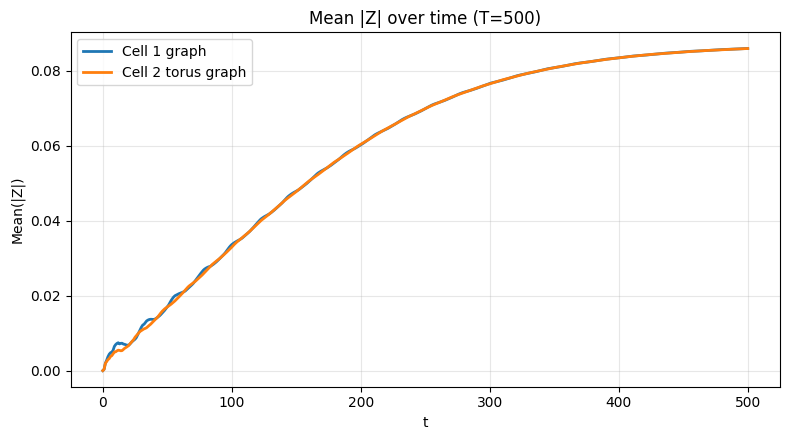

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm


def phi(z):
    return z / np.sqrt(1.0 + np.abs(z)**2)


def compute_mean_abs_curve(graph, T=500, I=0.0 + 0.01j, dt=1.0):
    n = graph.number_of_nodes()
    A_adj = nx.to_numpy_array(graph, nodelist=range(n), dtype=float)
    L = np.diag(A_adj.sum(axis=1)) - A_adj
    U = expm(1j * dt * L)

    z = np.zeros(n, dtype=np.complex128)
    I_vec = np.zeros(n, dtype=np.complex128)
    I_vec[0] = I

    t_axis = np.arange(T + 1)
    mean_abs = np.empty(T + 1, dtype=float)
    mean_abs[0] = np.mean(np.abs(z))

    for t in range(1, T + 1):
        z = phi(U @ z + I_vec)
        mean_abs[t] = np.mean(np.abs(z))

    return t_axis, mean_abs


if "G1" not in globals() or "G2" not in globals():
    raise RuntimeError("Run earlier cells first so G1 and G2 are available.")

T_plot = 500
I_plot = 0.0 + 0.01j

t1, mean1 = compute_mean_abs_curve(G1, T=T_plot, I=I_plot)
t2, mean2 = compute_mean_abs_curve(G2, T=T_plot, I=I_plot)

plt.figure(figsize=(8, 4.5))
plt.plot(t1, mean1, lw=2, label="Cell 1 graph")
plt.plot(t2, mean2, lw=2, label="Cell 2 torus graph")
plt.xlabel("t")
plt.ylabel("Mean(|Z|)")
plt.title(f"Mean |Z| over time (T={T_plot})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import hsv_to_rgb
import imageio.v2 as imageio


# ============================================================
# 1. SVG LOADING
# ============================================================

def parse_svg_path_to_polygon(d):
    """
    Very simple parser for the traced SVG paths in tiles_indexed.svg.
    Assumes path is effectively polygonal (M/L commands with numeric pairs).
    """
    nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', d)
    vals = list(map(float, nums))
    pts = np.array(list(zip(vals[0::2], vals[1::2])), dtype=float)

    # remove duplicate consecutive points if any
    if len(pts) >= 2:
        keep = [0]
        for i in range(1, len(pts)):
            if not np.allclose(pts[i], pts[keep[-1]]):
                keep.append(i)
        pts = pts[keep]

    return pts


def polygon_centroid(poly):
    """
    Area-weighted polygon centroid.
    Falls back to vertex mean if area ~ 0.
    """
    x = poly[:, 0]
    y = poly[:, 1]

    # close polygon
    x2 = np.r_[x, x[0]]
    y2 = np.r_[y, y[0]]

    cross = x2[:-1] * y2[1:] - x2[1:] * y2[:-1]
    A = 0.5 * np.sum(cross)

    if abs(A) < 1e-12:
        return np.array([np.mean(x), np.mean(y)])

    Cx = np.sum((x2[:-1] + x2[1:]) * cross) / (6 * A)
    Cy = np.sum((y2[:-1] + y2[1:]) * cross) / (6 * A)
    return np.array([Cx, Cy])


def polygon_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def load_indexed_svg(svg_path):
    """
    Loads the indexed SVG generated earlier.
    Returns:
        tiles: dict[tile_index] = {
            "poly": (N,2) array,
            "centroid": (2,) array,
            "area": float,
            "fill": original fill color string
        }

    Strategy:
    - parse all <path> elements as polygons
    - parse all <text> elements as tile IDs with coordinates
    - assign each text label to nearest polygon centroid
    """
    svg_path = Path(svg_path)
    tree = ET.parse(svg_path)
    root = tree.getroot()

    ns = {"svg": "http://www.w3.org/2000/svg"}

    path_elems = root.findall(".//svg:path", ns)
    text_elems = root.findall(".//svg:text", ns)

    polys = []
    for pe in path_elems:
        d = pe.attrib["d"]
        poly = parse_svg_path_to_polygon(d)
        cent = polygon_centroid(poly)
        area = polygon_area(poly)
        fill = pe.attrib.get("fill", "none")
        polys.append({
            "poly": poly,
            "centroid": cent,
            "area": area,
            "fill": fill
        })

    text_items = []
    for te in text_elems:
        if te.text is None:
            continue
        s = te.text.strip()
        if not s.isdigit():
            continue
        idx = int(s)
        x = float(te.attrib["x"])
        y = float(te.attrib["y"])
        text_items.append({
            "tile_index": idx,
            "pos": np.array([x, y], dtype=float)
        })

    # match each text label to nearest polygon centroid
    tiles = {}
    used_poly = set()

    for item in text_items:
        tile_idx = item["tile_index"]
        pos = item["pos"]

        dists = []
        for j, P in enumerate(polys):
            if j in used_poly:
                continue
            d = np.linalg.norm(P["centroid"] - pos)
            dists.append((d, j))

        dists.sort(key=lambda t: t[0])
        if not dists:
            raise RuntimeError(f"No polygon left to match tile {tile_idx}")

        _, best_j = dists[0]
        used_poly.add(best_j)
        tiles[tile_idx] = polys[best_j]

    if len(tiles) != len(polys):
        print(f"Warning: matched {len(tiles)} labels to {len(polys)} polygons")

    return tiles


# ============================================================
# 2. TILE -> NEURON ASSIGNMENT
# ============================================================

def neuron_label_to_graph_id(lbl):
    """
    Your convention:
      handwritten neuron 30 -> graph node 0
      handwritten neuron 1  -> graph node 1
      ...
      handwritten neuron 29 -> graph node 29
    """
    if lbl == 30:
        return 0
    return lbl


# ----------------------------------------------------------------
# FILL THIS IN FROM YOUR HANDWRITTEN IMAGE.
#
# Keys are tile indices from tiles_indexed.svg (1..90).
# Values are neuron labels from your handwritten annotation (1..30).
#
# Example placeholders only:
# ----------------------------------------------------------------
tile_to_neuron_label = {
    # tile_index : neuron_label
    # 1: 1,
    # 2: 2,
    # 3: 3,
    # ...
}

# sanity utility
def build_tile_to_graph_id(tile_to_neuron_label):
    tile_to_graph = {}
    for tile_idx, neuron_lbl in tile_to_neuron_label.items():
        tile_to_graph[tile_idx] = neuron_label_to_graph_id(neuron_lbl)
    return tile_to_graph


# ============================================================
# 3. COLOR MAPPING FROM COMPLEX STATE z
# ============================================================

def state_to_rgb(z, mag_scale=None, saturation=1.0):
    """
    z: complex vector of length 30, indexed by graph node IDs 0..29
    hue = phase
    value = magnitude / mag_scale
    """
    z = np.asarray(z, dtype=np.complex128)
    mag = np.abs(z)
    phase = np.angle(z)

    if mag_scale is None:
        mag_scale = np.percentile(mag, 99) if np.any(mag) else 1.0
    mag_scale = max(float(mag_scale), 1e-12)

    h = (phase + np.pi) / (2 * np.pi)
    s = np.full_like(h, fill_value=saturation, dtype=float)
    v = np.clip(mag / mag_scale, 0.0, 1.0)

    hsv = np.stack([h, s, v], axis=-1)
    rgb = hsv_to_rgb(hsv)
    return rgb


# ============================================================
# 4. DRAW ONE FRAME
# ============================================================

def draw_tiling_state(
    ax,
    tiles,
    tile_to_graph_id,
    z,
    mag_scale=None,
    show_tile_indices=False,
    show_neuron_ids=False,
    edgecolor="black",
    linewidth=0.8,
):
    """
    Draw the tiling colored by neural state z.

    tiles: dict from load_indexed_svg
    tile_to_graph_id: dict[tile_index] -> graph node ID in 0..29
    z: complex array length 30
    """
    rgb_nodes = state_to_rgb(z, mag_scale=mag_scale)

    patches = []
    facecolors = []

    for tile_idx in sorted(tiles.keys()):
        if tile_idx not in tile_to_graph_id:
            # unassigned tiles get gray
            color = (0.8, 0.8, 0.8)
        else:
            gid = tile_to_graph_id[tile_idx]
            color = rgb_nodes[gid]

        poly = tiles[tile_idx]["poly"]
        patches.append(Polygon(poly, closed=True))
        facecolors.append(color)

    pc = PatchCollection(
        patches,
        facecolor=facecolors,
        edgecolor=edgecolor,
        linewidth=linewidth
    )
    ax.add_collection(pc)

    if show_tile_indices:
        for tile_idx, item in tiles.items():
            cx, cy = item["centroid"]
            ax.text(cx, cy, str(tile_idx), ha="center", va="center", fontsize=8, color="black")

    if show_neuron_ids:
        for tile_idx, item in tiles.items():
            if tile_idx not in tile_to_graph_id:
                continue
            cx, cy = item["centroid"]
            gid = tile_to_graph_id[tile_idx]
            lbl = 30 if gid == 0 else gid
            ax.text(cx, cy, str(lbl), ha="center", va="center", fontsize=8, color="black")

    # fit bounds to geometry
    all_pts = np.vstack([tiles[k]["poly"] for k in tiles])
    xmin, ymin = all_pts.min(axis=0)
    xmax, ymax = all_pts.max(axis=0)

    pad = 10
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymax + pad, ymin - pad)  # invert y to match SVG coordinates
    ax.set_aspect("equal")
    ax.axis("off")


# ============================================================
# 5. EXAMPLE: USE WITH YOUR GRAPH DYNAMICS
# ============================================================

def phi(Z):
    return Z / np.sqrt(1.0 + np.abs(Z)**2)


def simulate_dynamics(U, T, z0=None, I_vec=None):
    """
    Returns Z_hist of shape (T, 30)
    """
    n = U.shape[0]
    if z0 is None:
        z = np.zeros(n, dtype=np.complex128)
    else:
        z = np.asarray(z0, dtype=np.complex128).copy()

    if I_vec is None:
        I_vec = np.zeros(n, dtype=np.complex128)
    else:
        I_vec = np.asarray(I_vec, dtype=np.complex128)

    Z_hist = np.zeros((T, n), dtype=np.complex128)
    for t in range(T):
        z = phi(U @ z + I_vec)
        Z_hist[t] = z
    return Z_hist


# ============================================================
# 6. MAKE A GIF
# ============================================================

def render_gif(
    out_gif,
    tiles,
    tile_to_graph_id,
    Z_hist,
    fps=15,
    show_neuron_ids=False,
    tmp_dir="frames_tmp"
):
    """
    Z_hist shape: (T, 30)
    """
    tmp_dir = Path(tmp_dir)
    tmp_dir.mkdir(exist_ok=True)

    mag_scale = np.percentile(np.abs(Z_hist), 99)
    mag_scale = max(float(mag_scale), 1e-12)

    frame_paths = []
    T = Z_hist.shape[0]

    for t in range(T):
        fig, ax = plt.subplots(figsize=(8, 8))
        draw_tiling_state(
            ax=ax,
            tiles=tiles,
            tile_to_graph_id=tile_to_graph_id,
            z=Z_hist[t],
            mag_scale=mag_scale,
            show_tile_indices=False,
            show_neuron_ids=show_neuron_ids
        )
        ax.set_title(f"t = {t}", fontsize=14)

        frame_path = tmp_dir / f"frame_{t:04d}.png"
        fig.savefig(frame_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        frame_paths.append(frame_path)

    images = [imageio.imread(fp) for fp in frame_paths]
    imageio.mimsave(out_gif, images, duration=1.0 / fps)

    print(f"Saved GIF to: {out_gif}")


# ============================================================
# 7. MAIN USAGE EXAMPLE
# ============================================================

if __name__ == "__main__":
    # ---- paths ----
    svg_path = "tiles_indexed.svg"   # the indexed SVG from earlier

    # ---- load geometry ----
    tiles = load_indexed_svg(svg_path)
    print(f"Loaded {len(tiles)} tiles from SVG")

    # ---- build tile -> graph node mapping ----
    tile_to_graph_id = build_tile_to_graph_id(tile_to_neuron_label)

    # Example sanity checks
    if len(tile_to_graph_id) > 0:
        counts = {}
        for tile_idx, gid in tile_to_graph_id.items():
            counts[gid] = counts.get(gid, 0) + 1
        print("Tiles per graph node:", dict(sorted(counts.items())))
        # ideally each graph node appears exactly 3 times

    # ---------------------------------------------------------
    # At this point, plug in your own U and I_vec from your graph code.
    # For demonstration below, I create dummy data.
    # Replace this block with your real simulation.
    # ---------------------------------------------------------
    n = 30
    T = 100

    # dummy circular-wave signal for testing the renderer
    Z_hist = np.zeros((T, n), dtype=np.complex128)
    for t in range(T):
        theta = 2 * np.pi * (np.arange(n) / n + t / T)
        mag = 0.5 + 0.5 * np.sin(2 * np.pi * t / T + np.arange(n) / 5.0)
        Z_hist[t] = mag * np.exp(1j * theta)

    # ---- draw one static frame ----
    if len(tile_to_graph_id) > 0:
        fig, ax = plt.subplots(figsize=(8, 8))
        draw_tiling_state(
            ax=ax,
            tiles=tiles,
            tile_to_graph_id=tile_to_graph_id,
            z=Z_hist[-1],
            mag_scale=np.percentile(np.abs(Z_hist), 99),
            show_tile_indices=False,
            show_neuron_ids=True
        )
        ax.set_title("Single frame")
        plt.tight_layout()
        plt.show()

        # ---- make GIF ----
        render_gif(
            out_gif="tiling_activity.gif",
            tiles=tiles,
            tile_to_graph_id=tile_to_graph_id,
            Z_hist=Z_hist,
            fps=15,
            show_neuron_ids=False
        )
    else:
        print("\nFill in tile_to_neuron_label first.")

Loaded 90 tiles from SVG

Fill in tile_to_neuron_label first.


In [7]:
# tile index (from tiles_indexed.svg) -> handwritten neuron label (1..30)
tile_to_neuron_label = {
    1: 2,   2: 23,  3: 17,  4: 26,  5: 1,   6: 3,   7: 18,  8: 25,  9: 19,  10: 17,
    11: 22, 12: 14, 13: 6,  14: 8,  15: 13, 16: 30, 17: 24, 18: 27, 19: 27, 20: 10,
    21: 20, 22: 28, 23: 12, 24: 15, 25: 29, 26: 21, 27: 4,  28: 29, 29: 13, 30: 14,
    31: 28, 32: 2,  33: 5,  34: 11, 35: 16, 36: 9,  37: 1,  38: 3,  39: 21, 40: 15,
    41: 10, 42: 4,  43: 12, 44: 20, 45: 16, 46: 23, 47: 9,  48: 17,  49: 11, 50: 24,
    51: 5,  52: 30, 53: 25, 54: 7,  55: 18, 56: 4,  57: 22, 58: 8,  59: 6,  60: 19,
    61: 10, 62: 26, 63: 26, 64: 9,  65: 21, 66: 20, 67: 5,  68: 17, 69: 27, 70: 23,
    71: 18, 72: 3,  73: 28, 74: 29, 75: 1,  76: 25, 77: 11, 78: 13, 79: 2,  80: 14,
    81: 16, 82: 30, 83: 12, 84: 15, 85: 24, 86: 8,  87: 19, 88: 22, 89: 6,  90: 7
}

Neuron-label counts:
  1: 3
  2: 3
  3: 3
  4: 3
  5: 3
  6: 3
  7: 3
  8: 3
  9: 3
  10: 3
  11: 3
  12: 3
  13: 3
  14: 3
  15: 3
  16: 3
  17: 3
  18: 3
  19: 3
  20: 3
  21: 3
  22: 3
  23: 3
  24: 3
  25: 3
  26: 3
  27: 3
  28: 3
  29: 3
  30: 3
All labels appear exactly 3 times.


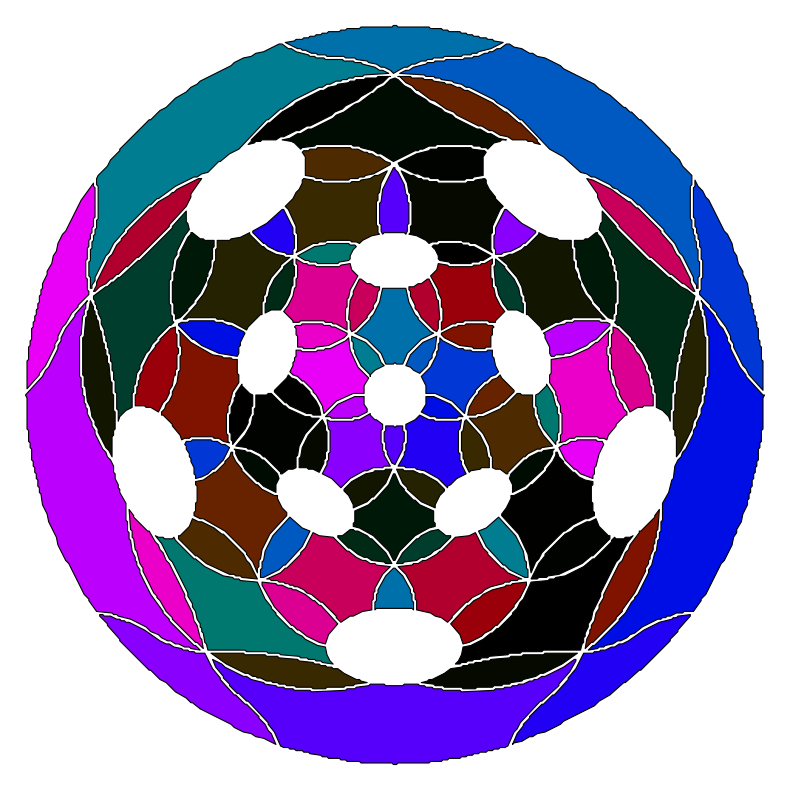

Saved GIF to tiling_activity.gif


In [8]:
import re
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import hsv_to_rgb
import imageio.v2 as imageio


# ============================================================
# A. TILE ASSIGNMENT FROM YOUR PHOTO
# ============================================================
# tile index (from tiles_indexed.svg) -> handwritten neuron label (1..30)
tile_to_neuron_label = {
    1: 2,   2: 23,  3: 17,  4: 26,  5: 1,   6: 3,   7: 18,  8: 25,  9: 19,  10: 7,
    11: 22, 12: 14, 13: 6,  14: 8,  15: 13, 16: 30, 17: 24, 18: 27, 19: 27, 20: 10,
    21: 20, 22: 28, 23: 12, 24: 15, 25: 29, 26: 21, 27: 4,  28: 29, 29: 13, 30: 14,
    31: 28, 32: 2,  33: 5,  34: 11, 35: 16, 36: 9,  37: 1,  38: 3,  39: 21, 40: 15,
    41: 10, 42: 4,  43: 12, 44: 20, 45: 16, 46: 23, 47: 9,  48: 17,  49: 11, 50: 24,
    51: 5,  52: 30, 53: 25, 54: 7,  55: 18, 56: 4,  57: 22, 58: 8,  59: 6,  60: 19,
    61: 10, 62: 26, 63: 26, 64: 9,  65: 21, 66: 20, 67: 5,  68: 17, 69: 27, 70: 23,
    71: 18, 72: 3,  73: 28, 74: 29, 75: 1,  76: 25, 77: 11, 78: 13, 79: 2,  80: 14,
    81: 16, 82: 30, 83: 12, 84: 15, 85: 24, 86: 8,  87: 19, 88: 22, 89: 6,  90: 7
}

def neuron_label_to_graph_id(lbl):
    # Your convention: handwritten 30 corresponds to graph node 0
    return 0 if lbl == 30 else lbl


def build_tile_to_graph_id(tile_to_neuron_label):
    return {tile_idx: neuron_label_to_graph_id(lbl)
            for tile_idx, lbl in tile_to_neuron_label.items()}


# ============================================================
# B. SVG GEOMETRY LOADING
# ============================================================

def parse_svg_path_to_polygon(d):
    nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', d)
    vals = list(map(float, nums))
    pts = np.array(list(zip(vals[0::2], vals[1::2])), dtype=float)

    if len(pts) >= 2:
        keep = [0]
        for i in range(1, len(pts)):
            if not np.allclose(pts[i], pts[keep[-1]]):
                keep.append(i)
        pts = pts[keep]

    return pts


def polygon_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_centroid(poly):
    x = poly[:, 0]
    y = poly[:, 1]

    x2 = np.r_[x, x[0]]
    y2 = np.r_[y, y[0]]

    cross = x2[:-1] * y2[1:] - x2[1:] * y2[:-1]
    A = 0.5 * np.sum(cross)

    if abs(A) < 1e-12:
        return np.array([np.mean(x), np.mean(y)])

    Cx = np.sum((x2[:-1] + x2[1:]) * cross) / (6 * A)
    Cy = np.sum((y2[:-1] + y2[1:]) * cross) / (6 * A)
    return np.array([Cx, Cy])


def load_indexed_svg(svg_path):
    """
    Loads your indexed SVG and matches polygon paths to the visible tile numbers.
    """
    svg_path = Path(svg_path)
    tree = ET.parse(svg_path)
    root = tree.getroot()

    ns = {"svg": "http://www.w3.org/2000/svg"}

    path_elems = root.findall(".//svg:path", ns)
    text_elems = root.findall(".//svg:text", ns)

    polys = []
    for pe in path_elems:
        d = pe.attrib.get("d")
        if not d:
            continue
        poly = parse_svg_path_to_polygon(d)
        if len(poly) < 3:
            continue
        polys.append({
            "poly": poly,
            "centroid": polygon_centroid(poly),
            "area": polygon_area(poly),
            "fill": pe.attrib.get("fill", "none")
        })

    text_items = []
    for te in text_elems:
        txt = (te.text or "").strip()
        if txt.isdigit():
            x = float(te.attrib["x"])
            y = float(te.attrib["y"])
            text_items.append({
                "tile_index": int(txt),
                "pos": np.array([x, y], dtype=float)
            })

    tiles = {}
    used = set()

    for item in text_items:
        tile_idx = item["tile_index"]
        pos = item["pos"]

        candidates = []
        for j, P in enumerate(polys):
            if j in used:
                continue
            d = np.linalg.norm(P["centroid"] - pos)
            candidates.append((d, j))

        candidates.sort(key=lambda x: x[0])
        if not candidates:
            raise RuntimeError(f"No polygon available for tile {tile_idx}")

        _, best_j = candidates[0]
        used.add(best_j)
        tiles[tile_idx] = polys[best_j]

    return tiles


# ============================================================
# C. COLORING: hue = phase, value = magnitude
# ============================================================

def state_to_rgb(z, mag_scale=None, saturation=1.0):
    z = np.asarray(z, dtype=np.complex128)
    mag = np.abs(z)
    phase = np.angle(z)

    if mag_scale is None:
        mag_scale = np.percentile(mag, 99) if np.any(mag) else 1.0
    mag_scale = max(float(mag_scale), 1e-12)

    h = (phase + np.pi) / (2 * np.pi)            # hue from phase
    s = np.full_like(h, saturation, dtype=float) # fixed saturation
    v = np.clip(mag / mag_scale, 0.0, 1.0)       # brightness from |z|

    hsv = np.stack([h, s, v], axis=-1)
    return hsv_to_rgb(hsv)


# ============================================================
# D. DRAW A SINGLE FRAME
# ============================================================

def draw_tiling_state(ax, tiles, tile_to_graph_id, z, mag_scale=None,
                      show_tile_indices=False, show_graph_ids=False,
                      edgecolor="black", linewidth=0.8):
    rgb_nodes = state_to_rgb(z, mag_scale=mag_scale)

    patches = []
    facecolors = []

    for tile_idx in sorted(tiles.keys()):
        poly = tiles[tile_idx]["poly"]
        gid = tile_to_graph_id[tile_idx]
        color = rgb_nodes[gid]

        patches.append(Polygon(poly, closed=True))
        facecolors.append(color)

    pc = PatchCollection(
        patches,
        facecolor=facecolors,
        edgecolor=edgecolor,
        linewidth=linewidth
    )
    ax.add_collection(pc)

    if show_tile_indices:
        for tile_idx, item in tiles.items():
            cx, cy = item["centroid"]
            ax.text(cx, cy, str(tile_idx), ha="center", va="center", fontsize=8, color="black")

    if show_graph_ids:
        for tile_idx, item in tiles.items():
            cx, cy = item["centroid"]
            gid = tile_to_graph_id[tile_idx]
            ax.text(cx, cy, str(gid), ha="center", va="center", fontsize=8, color="black")

    all_pts = np.vstack([tiles[k]["poly"] for k in tiles])
    xmin, ymin = all_pts.min(axis=0)
    xmax, ymax = all_pts.max(axis=0)
    pad = 10

    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymax + pad, ymin - pad)  # invert y to match SVG coordinates
    ax.set_aspect("equal")
    ax.axis("off")


# ============================================================
# E. SIMULATION HISTORY
# ============================================================

def phi(Z):
    return Z / np.sqrt(1.0 + np.abs(Z)**2)


def simulate_dynamics(U, T, z0=None, I_vec=None):
    n = U.shape[0]

    if z0 is None:
        z = np.zeros(n, dtype=np.complex128)
    else:
        z = np.asarray(z0, dtype=np.complex128).copy()

    if I_vec is None:
        I_vec = np.zeros(n, dtype=np.complex128)
    else:
        I_vec = np.asarray(I_vec, dtype=np.complex128)

    Z_hist = np.zeros((T, n), dtype=np.complex128)

    for t in range(T):
        z = phi(U @ z + I_vec)
        Z_hist[t] = z

    return Z_hist


# ============================================================
# F. GIF RENDERING
# ============================================================

def render_gif(out_gif, tiles, tile_to_graph_id, Z_hist, fps=15,
               show_graph_ids=False, tmp_dir="frames_tmp"):
    tmp_dir = Path(tmp_dir)
    tmp_dir.mkdir(exist_ok=True)

    mag_scale = np.percentile(np.abs(Z_hist), 99)
    mag_scale = max(float(mag_scale), 1e-12)

    frame_paths = []

    for t in range(Z_hist.shape[0]):
        fig, ax = plt.subplots(figsize=(8, 8))
        draw_tiling_state(
            ax=ax,
            tiles=tiles,
            tile_to_graph_id=tile_to_graph_id,
            z=Z_hist[t],
            mag_scale=mag_scale,
            show_tile_indices=False,
            show_graph_ids=show_graph_ids
        )
        ax.set_title(f"t = {t}")
        frame_path = tmp_dir / f"frame_{t:04d}.png"
        fig.savefig(frame_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        frame_paths.append(frame_path)

    images = [imageio.imread(fp) for fp in frame_paths]
    imageio.mimsave(out_gif, images, duration=1.0 / fps)
    print(f"Saved GIF to {out_gif}")


# ============================================================
# G. SANITY CHECKS
# ============================================================

def check_assignment(tile_to_neuron_label):
    counts = Counter(tile_to_neuron_label.values())
    print("Neuron-label counts:")
    for k in sorted(counts):
        print(f"  {k}: {counts[k]}")
    bad = [k for k, v in counts.items() if v != 3]
    if bad:
        print("WARNING: these labels do not appear exactly 3 times:", bad)
    else:
        print("All labels appear exactly 3 times.")


# ============================================================
# H. EXAMPLE USAGE
# ============================================================

if __name__ == "__main__":
    # 1. load geometry
    svg_path = "tiles_indexed.svg"
    tiles = load_indexed_svg(svg_path)

    # 2. assignment
    check_assignment(tile_to_neuron_label)
    tile_to_graph_id = build_tile_to_graph_id(tile_to_neuron_label)

    # 3. EXAMPLE ONLY:
    # Replace this block with your real Z_hist from your graph dynamics.
    T = 10
    n = 30


    # 4. draw one frame
    fig, ax = plt.subplots(figsize=(8, 8))
    draw_tiling_state(ax, tiles, tile_to_graph_id, Z_hist[-1],
                      mag_scale=np.percentile(np.abs(Z_hist), 99),
                      show_tile_indices=False,
                      show_graph_ids=False)
    plt.tight_layout()
    plt.show()

    # 5. GIF
    render_gif("tiling_activity.gif", tiles, tile_to_graph_id, Z_hist, fps=15)